# Численные методы №2.5

In [1]:
from numpy import sqrt, linspace
import matplotlib.pyplot as plt
import pandas as pd

## Задание 1.

Сопоставляя рис. 2.10, 2.11 и 2.12, проиллюстрируйте графически решение уравнения методами хорд и касательных для всех четырех ситуаций, изображенных на рис. 2.9.

C:\Users\User\AppData\Local\Temp\ipykernel_21920\921915953.py:5: RuntimeWarning: invalid value encountered in sqrt
  lambda x: -np.sqrt(x - 1) + 0.5,
C:\Users\User\AppData\Local\Temp\ipykernel_21920\921915953.py:6: RuntimeWarning: invalid value encountered in sqrt
  lambda x: np.sqrt(2.5 - x) - 0.5


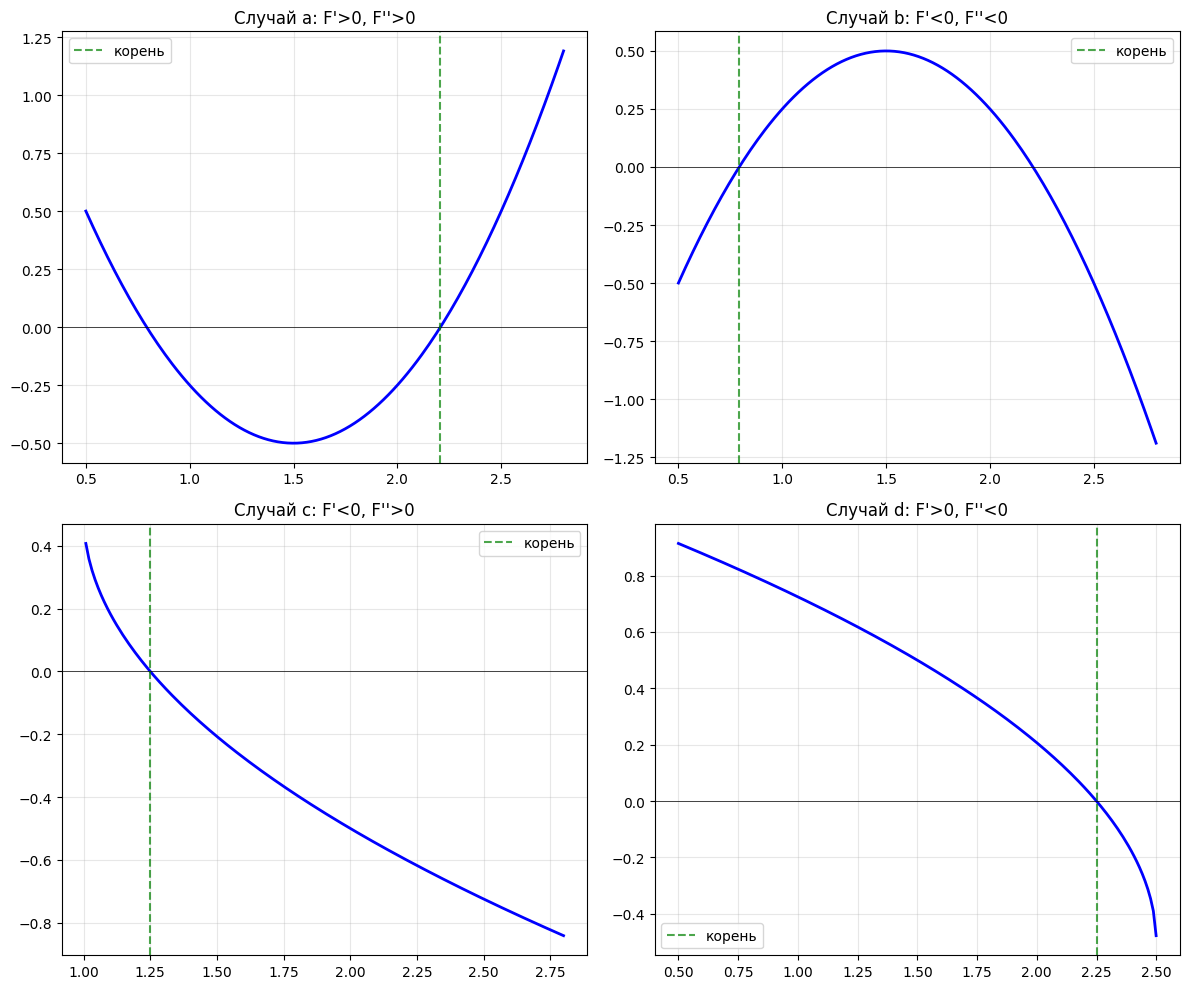

In [ ]:
#4 разных случая(на 4 картинки)
funcs = [
    lambda x: (x - 1.5) ** 2 - 0.5,           
    lambda x: -(x - 1.5) ** 2 + 0.5,           
    lambda x: -sqrt(x - 1) + 0.5,         
    lambda x: sqrt(2.5 - x) - 0.5         
]

#теор смысл
titles = ["F'>0, F''>0", "F'<0, F''<0", "F'<0, F''>0", "F'>0, F''<0"]
#корни
roots = [1.5 + sqrt(0.5), 1.5 - sqrt(0.5), 1.25, 2.25]

#
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for i, (f, title, root) in enumerate(zip(funcs, titles, roots)):
    #область определения и значения
    x = linspace(0.5, 2.8, 200)
    y = f(x)

    #график функ
    axes[i].plot(x, y, 'b-', linewidth=2)
    #оси координат
    axes[i].axhline(0, color='black', linewidth=0.5)
    #Отметка корня
    axes[i].axvline(root, color='g', linestyle='--', alpha=0.7, label='корень')
    #график(оформление)
    axes[i].set_title(f'Случай {chr(97+i)}: {title}')
    axes[i].grid(True, alpha=0.3)
    axes[i].legend()

plt.tight_layout()
plt.show()

## Задание 2.

Комбинированным методом хорд и касательных уточните до 0,000001 корень уравнения x^3 + 3x^2 - 24x + 1 = 0 расположенный на отрезке [0; 1].

In [8]:
def f(x):
    return x**3 + 3*x**2 - 24*x + 1

def df(x):
    return 3*x**2 + 6*x - 24

def solve_combined(a, b, eps):
    data = []
    iteration = 0
    
    # Т.к. f' < 0 и f'' > 0 на [0, 1]:
    # a_next вычисляется методом касательных
    # b_next вычисляется методом хорд
    
    while abs(b - a) > eps:
        iteration += 1
        
        # Сохраняем текущие значения
        data.append({
            'Итерация': iteration,
            'a (касательные)': a,
            'b (хорды)': b,
            'f(a)': f(a),
            'f(b)': f(b),
            '|b - a|': abs(b - a)
        })
        
        # Уточнение границы a методом касательных
        a_next = a - f(a) / df(a)
        
        # Уточнение границы b методом хорд
        b_next = b - (f(b) * (b - a)) / (f(b) - f(a))
        
        a, b = a_next, b_next
        
        if iteration > 20:  # Предохранитель
            break

    return pd.DataFrame(data), (a + b) / 2

# Начальные данные
a_0, b_0 = 0.0, 1.0
eps = 0.000001

df_res, root = solve_combined(a_0, b_0, eps)

# Вывод результатов
pd.options.display.float_format = '{:.8f}'.format
display(df_res)
print(f"\nУточненный корень: {root:.7f}")

,Итерация,a (касательные),b (хорды),f(a),f(b),|b - a|
0,1,0.00000000,1.00000000,1.00000000,-19.00000000,1.00000000
1,2,0.04166667,0.05000000,0.00528067,-0.19237500,0.00833333



Уточненный корень: 0.0418892
